# Détection de Fraude (Partie 2) : Modélisation et Évaluation

**Objectif de ce document :** Charger les données précédemment nettoyées et équilibrées (SMOTE) pour entraîner le cerveau artificiel, puis évaluer sa capacité à repérer les fraudes dans des conditions réelles.

---
## Transition : Importation de l'Espace de Travail
En miroir de l'exportation réalisée à la fin de la Phase 3, recharger les données nettoyées, mises à l'échelle et parfaitement équilibrées (SMOTE) depuis le disque dur grâce à `joblib`.

In [1]:
import joblib
X_train_smote = joblib.load('X_train_smote.pkl')
y_train_smote = joblib.load('y_train_smote.pkl')
X_test = joblib.load('X_test.pkl')
y_test = joblib.load('y_test.pkl')
print("Données importées avec succès !")
print("Taille du jeu d'entraînement équilibré (X_train_smote) :", X_train_smote.shape)

Données importées avec succès !
Taille du jeu d'entraînement équilibré (X_train_smote) : (454902, 30)


## Phase 4 : Modélisation (Entraînement de l'algorithme)

Définition et entraînement d'un modèle de référence (Baseline) : la **Régression Logistique**. 
L'objectif de cette étape est d'optimiser les poids de l'algorithme sur le jeu de données d'apprentissage équilibré (SMOTE) afin d'établir une frontière de décision mathématique capable de séparer les transactions légitimes des transactions frauduleuses.

In [2]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_smote, y_train_smote)
print("Entraînement terminé. Le modèle est prêt pour l'évaluation.")

Entraînement terminé. Le modèle est prêt pour l'évaluation.


## Phase 5 : Évaluation des Performances

Analyse de la capacité du modèle de Régression Logistique à généraliser sur des données inédites. L'évaluation repose sur la génération de prédictions à partir du jeu de test (`X_test`), suivie d'une analyse des métriques via un rapport de classification et une matrice de confusion.

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.93      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



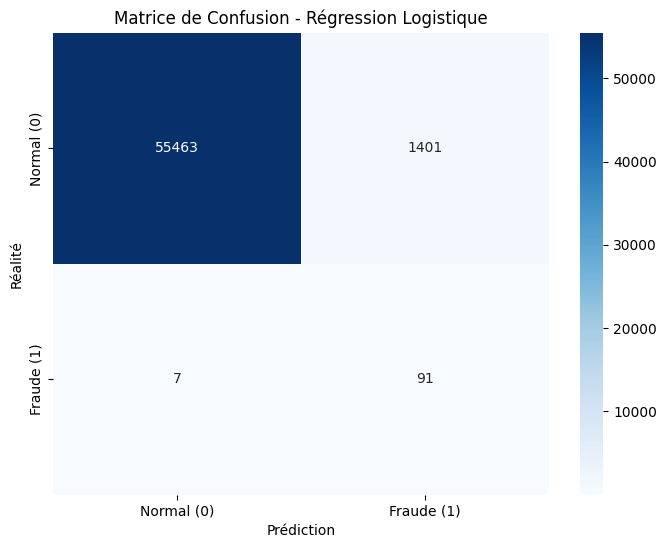

In [3]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
y_pred = log_reg.predict(X_test)
print(classification_report(y_test, y_pred))
matrice = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(matrice, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal (0)', 'Fraude (1)'], 
            yticklabels=['Normal (0)', 'Fraude (1)'])
plt.ylabel('Réalité')
plt.xlabel('Prédiction')
plt.title('Matrice de Confusion - Régression Logistique')
plt.show()

## Phase 6 : Modélisation Avancée (Forêt Aléatoire)

Afin d'optimiser la frontière de décision et de réduire le taux de Faux Positifs généré par le modèle de base, implémentation d'un modèle non linéaire : la **Forêt Aléatoire (Random Forest)**. 

In [4]:
from sklearn.ensemble import RandomForestClassifier
rf_clf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf_clf.fit(X_train_smote, y_train_smote)
print("Entraînement de la Forêt Aléatoire terminé avec succès !")

Entraînement de la Forêt Aléatoire terminé avec succès !


**Évaluation de la Forêt Aléatoire**
Génération des prédictions sur le jeu de test et analyse comparative de la matrice de confusion pour vérifier la réduction des Faux Positifs par rapport au modèle de référence.

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.41      0.89      0.56        98

    accuracy                           1.00     56962
   macro avg       0.71      0.94      0.78     56962
weighted avg       1.00      1.00      1.00     56962



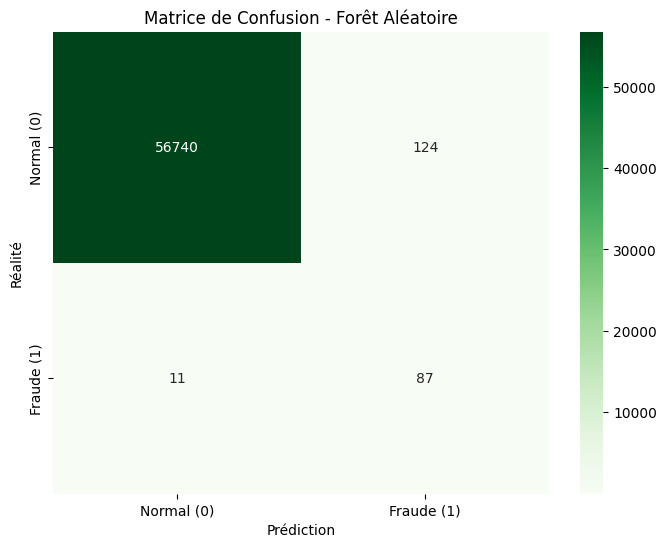

In [5]:
y_pred_rf = rf_clf.predict(X_test)
print(classification_report(y_test, y_pred_rf))
matrice_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(matrice_rf, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Normal (0)', 'Fraude (1)'], 
            yticklabels=['Normal (0)', 'Fraude (1)'])
plt.ylabel('Réalité')
plt.xlabel('Prédiction')
plt.title('Matrice de Confusion - Forêt Aléatoire')
plt.show()